--- Initial Environment State ---
Metadata Only: [0. 0. 0. 0. 0.]
Initial Info: {'price': 100.0, 'shares': 0, 'friction_leak': 0.0, 'cash': 1000, 'step': 0}
---------------------------------

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Starting Training Loop...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -0.512   |
| time/              |          |
|    fps             | 4410     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 200          |
|    ep_rew_mean          | -0.273       |
| time/                   |              |
|    fps                  | 2908         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|   

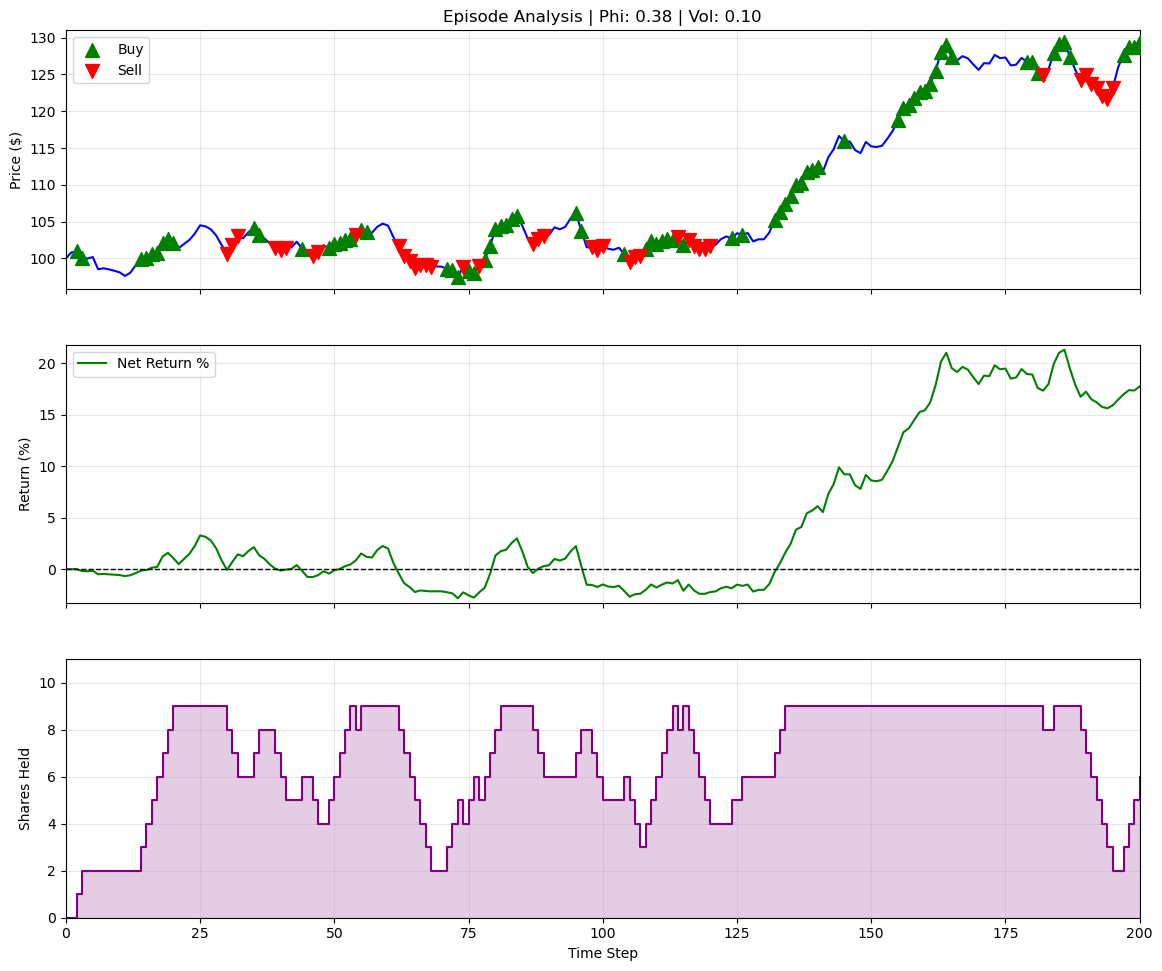


Final Test Episode Finished.
Total Reward: 1.60
Final Info: {'price': 129.38231896264404, 'shares': 6, 'friction_leak': 0.12869636608642862, 'cash': 401.21710904414033, 'step': 200}


In [2]:
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold
import matplotlib.pyplot as plt

from spectral_env_core import SpectralTradingEnv

# --- 1. Setup Environment Variables ---
# You can easily adjust these parameters here
env_kwargs = {
    "num_steps": 200,
    "time_total": 1.0,
    "initial_price": 100.0,
    "volatility": 0.1,
    "df" : 15,
    "transaction_cost_pct": 0.001,
    "drift": 0.05,
    "max_shares": 10,
    "starting_cash": 1000, # Increased for better visibility
}

if __name__ == "__main__":
    # --- 2. Initialize Environments ---
    # Training env (no rendering)
    env = SpectralTradingEnv(**env_kwargs, render_mode=None)
    # Evaluation env (for the callback to check performance)
    eval_env = SpectralTradingEnv(**env_kwargs, render_mode=None)

    # Print Initial State Info as requested
    obs, info = env.reset()
    print("--- Initial Environment State ---")
    print("Metadata Only:", obs[:5])# [Price, Cash, Shares, Portfolio]
    print("Initial Info:", info)
    print("---------------------------------\n")

    # --- 3. Define Model and Callbacks ---
    # Increased ent_coef to force the agent to stop holding 0 shares
    # --- 3. Define Model and Callbacks ---
    model = PPO(
        "MlpPolicy", 
        env, 
        verbose=1, 
        device='cpu',
        n_steps=2048,          # Number of steps to run for each environment per update
        batch_size=64,         # Minibatch size for each gradient update
        gamma=0.99,            # Discount factor (0.99 is standard for long-term rewards)
        ent_coef=0.05,         # Keeps the agent exploring
        learning_rate=0.0001,
        target_kl=0.01   # Standard starting rate for PPO
    )
    '''
    # Stop training when mean reward hits 50
    callback_on_best = StopTrainingOnRewardThreshold(reward_threshold=50, verbose=1)
    eval_callback = EvalCallback(eval_env, 
                                 callback_on_new_best=callback_on_best, 
                                 verbose=1, 
                                 eval_freq=100000)
    '''

    # --- 4. Train the Agent ---
    print("Starting Training Loop...")
    model.learn(total_timesteps=1000000)

    # --- 5. Final Detailed Testing (Post-Training) ---
    print("\n--- Testing Trained Agent (Detailed Info) ---")
    
    env_test = SpectralTradingEnv(**env_kwargs, render_mode='human')
    obs, info = env_test.reset()
    
    total_reward = 0
    for step in range(env_test.num_steps):
        # 1. Predict
        action, _states = model.predict(obs, deterministic=True)
        
        # 2. Step the environment
        obs, reward, terminated, truncated, info = env_test.step(action)
        total_reward += reward
        
        # 3. TRIGGER THE RENDER (This is the missing link!)
        #env_test.render() 
        
        # 4. Optional Printing
        if step % 50 == 0:
             # Using the new keys defined in your _get_info method
             print(f"Step {step}: Price={info['price']:.2f}, "
                   f"Shares={info['shares']}, "
                   f"Cash= {info['cash']}"
                   )

        if terminated or truncated:
            break

    # 3. TRIGGER THE RENDER (This is the missing link!)
    env_test.render() 

    print(f"\nFinal Test Episode Finished.")
    print(f"Total Reward: {total_reward:.2f}")
    print("Final Info:", info) # Now you see final Cash/Shares/Portfolio
    
    # Keep the plot open
    if env_test.render_mode == 'human':
        plt.ioff()
        plt.show()
        plt.show(block=True)

    env_test.close()